In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Прочитайте данные (переменную назовите 'df')
df = pd.read_csv('data.csv')

# Вывести несколько первых строк таблицы данных
print(df.head())

         Дата  Склад Контрагент Номенклатура  Количество
0  2018-01-04      1  address_0    product_0           4
1  2018-01-04      1  address_0    product_1           4
2  2018-01-04      1  address_0    product_2           5
3  2018-01-04      1  address_0    product_3          10
4  2018-01-04      1  address_0    product_4           2


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301355 entries, 0 to 301354
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   Дата          301355 non-null  object
 1   Склад         301355 non-null  int64 
 2   Контрагент    301355 non-null  object
 3   Номенклатура  301355 non-null  object
 4   Количество    301355 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.5+ MB


Проверяем формат столбцов

In [6]:
df['Дата'] = pd.to_datetime(df['Дата'])

print(df['Дата'].dtype)

datetime64[ns]


Сразу переведем столбец "Дата" в правильный формат

In [7]:
grouped_df = df.groupby('Дата')['Количество'].sum().reset_index()

Сгруппируйте данные по дате, посчитайте количество продаж

In [ ]:
grouped_df = ...

Вывести несколько первых строк сгруппированных данных

In [8]:
print(grouped_df.head())

        Дата  Количество
0 2018-01-04        3734
1 2018-01-05        3643
2 2018-01-06        3193
3 2018-01-07        3298
4 2018-01-09        4055


Нарисуйте график продаж у `grouped_df`

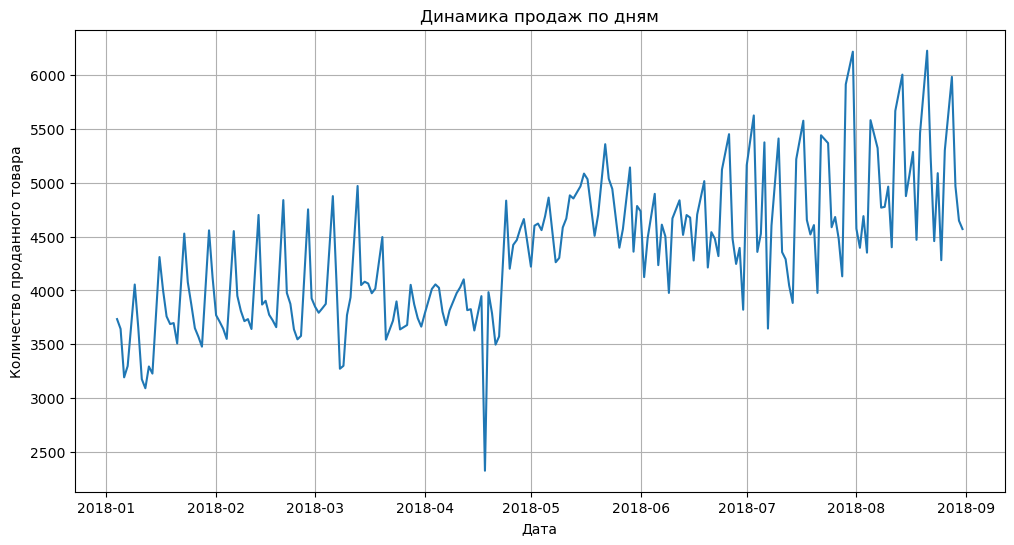

In [9]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=grouped_df, x='Дата', y='Количество')

plt.title('Динамика продаж по дням')
plt.xlabel('Дата')
plt.ylabel('Количество проданного товара')
plt.grid(True)
plt.show()

Опишите что вы видите на графике. Ваша задача - максимально описать график

In [10]:
'''
АНАЛИЗ ГРАФИКА ДИНАМИКИ ПРОДАЖ:

1. ОБЩИЙ ТРЕНД: Наблюдается выраженный восходящий тренд. Продажи в начале года 
   начинались с уровня ~3500 единиц и к июню выросли до пиковых значений >5500 единиц.

2. СЕЗОННОСТЬ И ЦИКЛИЧНОСТЬ: 
   - На графике видна четкая еженедельная цикличность (характерные "зубья" пилы). 
   - Регулярные всплески и падения указывают на зависимость от дней недели 
     (например, рост к выходным и спад в начале недели).

3. АНОМАЛИИ: 
   - В середине апреля (перед отметкой 2018-05) наблюдается резкое падение продаж 
     ниже 2500 единиц. Это самая глубокая точка на графике, которая может быть 
     связана с техническим сбоем, праздниками или отсутствием поставок.
   - Сразу после этого провала в мае виден резкий скачок и переход на новый, 
     более высокий уровень стабильных продаж (выше 4500).

4. ВОЛАТИЛЬНОСТЬ: Размах колебаний (разница между пиком и спадом внутри недели) 
   составляет около 1000-1500 единиц, что говорит о высокой динамичности спроса.

ВЫВОД: Бизнес демонстрирует уверенный рост, однако аномальный провал в апреле 
требует дополнительного исследования причин.
'''

'\nАНАЛИЗ ГРАФИКА ДИНАМИКИ ПРОДАЖ:\n\n1. ОБЩИЙ ТРЕНД: Наблюдается выраженный восходящий тренд. Продажи в начале года \n   начинались с уровня ~3500 единиц и к июню выросли до пиковых значений >5500 единиц.\n\n2. СЕЗОННОСТЬ И ЦИКЛИЧНОСТЬ: \n   - На графике видна четкая еженедельная цикличность (характерные "зубья" пилы). \n   - Регулярные всплески и падения указывают на зависимость от дней недели \n     (например, рост к выходным и спад в начале недели).\n\n3. АНОМАЛИИ: \n   - В середине апреля (перед отметкой 2018-05) наблюдается резкое падение продаж \n     ниже 2500 единиц. Это самая глубокая точка на графике, которая может быть \n     связана с техническим сбоем, праздниками или отсутствием поставок.\n   - Сразу после этого провала в мае виден резкий скачок и переход на новый, \n     более высокий уровень стабильных продаж (выше 4500).\n\n4. ВОЛАТИЛЬНОСТЬ: Размах колебаний (разница между пиком и спадом внутри недели) \n   составляет около 1000-1500 единиц, что говорит о высокой дина

Найдите строку, у которой максимальный выброс по количеству продаж (нужно найти выброс у `df`)

In [11]:
outlier_row = df[df['Количество'] == df['Количество'].max()]

print(outlier_row)

             Дата  Склад   Контрагент Номенклатура  Количество
218822 2018-06-28      1  address_208    product_0         200


Найдите топовый товар по продажам по средам за июнь, июль, август у 3 склада

In [12]:
# 1. Фильтруем по складу и летним месяцам
summer_filter = (df['Склад'] == 3) & (df['Дата'].dt.month.isin([6, 7, 8]))

# 2. Добавляем фильтр по средам (dayofweek == 2)
wednesday_filter = (df['Дата'].dt.dayofweek == 2)

# Применяем фильтры и находим топовый товар
top_product = (df[summer_filter & wednesday_filter]
               .groupby('Номенклатура')['Количество']
               .sum()
               .sort_values(ascending=False)
               .head(1))

print("Топовый товар по средам летом для 3 склада:")
print(top_product)

Топовый товар по средам летом для 3 склада:
Номенклатура
product_1    2267
Name: Количество, dtype: int64


Скачайте данные по погоде с https://rp5.ru/Архив_погоды_в_Астане (скачайте исходные данные, и далее преобразуйте так, чтобы мы имели Дату и Среднюю температуру за день), объедините таблицу температуры с `grouped_df`, и нарисуйте график `y=['Количество продаж', 'T']`, где Т это температура. А также отдельно график температуры.

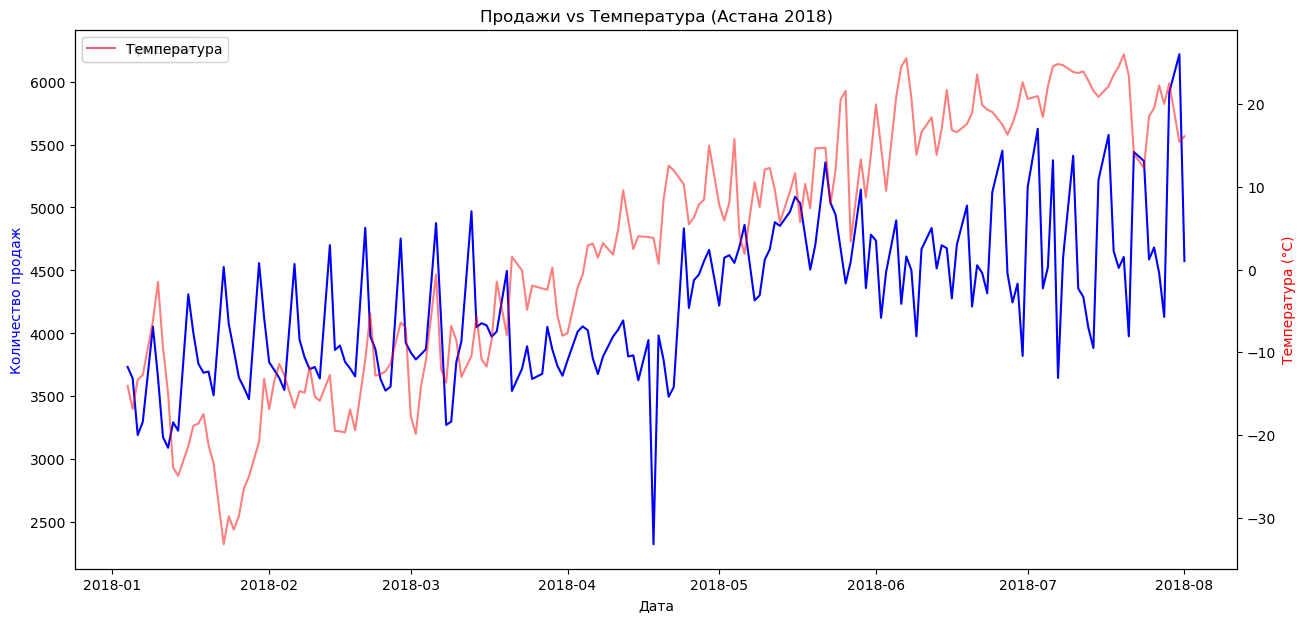

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Читаем файл (убедись, что файл лежит в той же папке)
file_name = 'WeatherAstana.xlsx'
df_weather = pd.read_excel(file_name)

# 2. Выбираем колонки (0-я это время, 1-я это температура)
df_weather = df_weather.iloc[:, [0, 1]]
df_weather.columns = ['DateTime', 'T']

# 3. ПРЕОБРАЗОВАНИЕ ДАТ (Исправляем твою ошибку здесь)
# Добавляем dayfirst=True, чтобы 31.07 распознавалось правильно
df_weather['Дата'] = pd.to_datetime(df_weather['DateTime'], dayfirst=True).dt.normalize()

# 4. Группируем по дням (средняя температура)
daily_weather = df_weather.groupby('Дата')['T'].mean().reset_index()

# 5. ОБЪЕДИНЕНИЕ С ПРОДАЖАМИ
# Проверь, что в grouped_df есть колонка 'Дата'
grouped_df['Дата'] = pd.to_datetime(grouped_df['Дата']).dt.normalize()
final_df = pd.merge(grouped_df, daily_weather, on='Дата', how='inner')

# 6. ГРАФИКИ
if not final_df.empty:
    fig, ax1 = plt.subplots(figsize=(15, 7))

    # Продажи
    sns.lineplot(data=final_df, x='Дата', y='Количество', ax=ax1, color='blue', label='Продажи')
    ax1.set_ylabel('Количество продаж', color='blue')

    # Температура
    ax2 = ax1.twinx()
    sns.lineplot(data=final_df, x='Дата', y='T', ax=ax2, color='red', label='Температура', alpha=0.5)
    ax2.set_ylabel('Температура (°C)', color='red')

    plt.title('Продажи vs Температура (Астана 2018)')
    plt.show()
else:
    print("Даты не совпали. Проверь даты в grouped_df и WeatherAstana.")